In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 33.1 MB/s eta 0:00:00


In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.stats import skew
import joblib

from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, recall_score, f1_score, classification_report, confusion_matrix

In [ ]:
# Hàm đọc dữ liệu từ thư mục folder
def load_images_from_folder(folder):
    images = []
    labels = []
    class_names = sorted(os.listdir(folder))

    for label, class_name in enumerate(class_names):
        class_folder = os.path.join(folder, class_name)
        if os.path.isdir(class_folder):
            for filename in sorted(os.listdir(class_folder)):
                img_path = os.path.join(class_folder, filename)
                img = cv2.imread(img_path)
                if img is not None:
                    images.append(img)
                    labels.append(label)

    return images, labels, class_names

In [ ]:
# Đọc dữ liệu từ thư mục Dataset
train_folder  = "/content/drive/MyDrive/UIT/dataset/train"
test_folder   = "/content/drive/MyDrive/UIT/dataset/test"

train_images, train_labels, class_names = load_images_from_folder(train_folder)
test_images, test_labels, _ = load_images_from_folder(test_folder)

In [ ]:
print(f"Nhãn các class: {class_names}")
print(f"Tổng số ảnh trong tập train: {len(train_images)}")
print(f"Tổng số ảnh trong tập test: {len(test_images)}")

Nhãn các class: ['Overripe', 'Ripe', 'Unripe']
Tổng số ảnh trong tập train: 480
Tổng số ảnh trong tập test: 120


In [ ]:
# Hàm hiển thị một ảnh
def show_image(image, title="Image", size=5):
    """
    Hàm hiển thị một ảnh duy nhất.
    - image: Mảng ảnh (numpy array).
    - title: Tiêu đề ảnh.
    - size: Kích thước hiển thị (inch).
    """
    plt.figure(figsize=(size, size))

    # Chuyển đổi màu nếu ảnh có 3 kênh (thường là BGR từ OpenCV)
    if len(image.shape) == 3:
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        plt.imshow(image_rgb)
    else:
        # Hiển thị ảnh xám (grayscale)
        plt.imshow(image, cmap='gray')

    plt.title(title)
    plt.axis('off')
    plt.show()

# Cách dùng:
# show_image(train_images[0], title="Ảnh đầu tiên", size=6)

# Công đoạn phân đoạn chuối và chỉnh mask chuối về 224x224


In [ ]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
model_yolo = YOLO('yolov8x-seg.pt')


0: 640x480 1 banana, 6240.5ms
1: 640x480 1 banana, 6240.5ms
2: 640x480 1 banana, 6240.5ms
3: 640x480 1 banana, 6240.5ms
4: 640x480 1 banana, 6240.5ms
5: 640x480 1 banana, 6240.5ms
6: 640x480 1 banana, 6240.5ms
7: 640x480 1 banana, 6240.5ms
8: 640x480 1 banana, 6240.5ms
Speed: 5.7ms preprocess, 6240.5ms inference, 10.6ms postprocess per image at shape (1, 3, 640, 480)


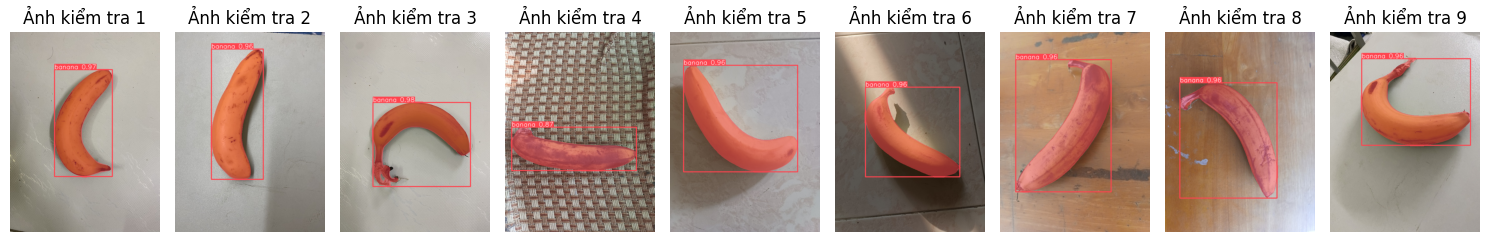

In [ ]:
# Nhặt từng ảnh ở vị trí bạn muốn và gom vào một mảng mới
images_to_test = [
    train_images[8],
    train_images[160],
    train_images[320],
    train_images[125],
    train_images[250],
    train_images[479],
    train_images[156],
    train_images[146],
    train_images[386],
]

# Sau đó đưa mảng này vào YOLO như bình thường
results = model_yolo.predict(source=images_to_test, classes=[46])

plt.figure(figsize=(15, 5)) # Chỉnh kích thước khung hiển thị

for i, result in enumerate(results):
    # result.plot() tự động vẽ box và mask mặc định của YOLO
    img_plotted = result.plot()

    # Đổi BGR (OpenCV) sang RGB (Matplotlib)
    img_rgb = cv2.cvtColor(img_plotted, cv2.COLOR_BGR2RGB)

    # Đưa từng ảnh vào khung hiển thị
    plt.subplot(1, len(images_to_test), i + 1)
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.title(f"Ảnh kiểm tra {i+1}")

plt.tight_layout()
plt.show()

In [ ]:
def process_banana_224(img, img_idx=None, debug=False):
    h_orig, w_orig = img.shape[:2]

    results = model_yolo.predict(source=img, verbose=False)
    result = results[0]

    if result.masks is None or len(result.masks.xy) == 0:
        print(f"(!) Ảnh {img_idx}: YOLO không detect")
        return None, None

    # TÌM MASK LỚN NHẤT (dựa trên diện tích bounding box)
    boxes_np = result.boxes.xyxy.cpu().numpy()
    areas = [(box[2] - box[0]) * (box[3] - box[1]) for box in boxes_np]
    idx = np.argmax(areas)

    # MASK YOLO: Dùng tọa độ Polygon
    polygon = result.masks.xy[idx].astype(np.int32)
    mask = np.zeros((h_orig, w_orig), dtype=np.uint8)
    cv2.fillPoly(mask, [polygon], 255)

    x1, y1, x2, y2 = result.boxes.xyxy[idx].cpu().numpy().astype(int)

    x1, y1 = max(0, x1), max(0, y1)
    x2, y2 = min(w_orig, x2), min(h_orig, y2)

    banana_only = cv2.bitwise_and(img, img, mask=mask)
    cropped = banana_only[y1:y2, x1:x2]

    if cropped.size == 0:
        print(f"(!) Ảnh {img_idx}: crop lỗi (kích thước = 0)")
        return None, None

    ch, cw = cropped.shape[:2]
    max_side = max(ch, cw)

    # Khởi tạo ảnh vuông nền đen (PADDING)
    square_img = np.zeros((max_side, max_side, 3), dtype=np.uint8)
    y_off, x_off = (max_side - ch) // 2, (max_side - cw) // 2
    square_img[y_off:y_off+ch, x_off:x_off+cw] = cropped

    final_img = cv2.resize(square_img, (224, 224), interpolation=cv2.INTER_AREA)

    # Crop và pad cho mask tương tự như ảnh
    mask_crop = mask[y1:y2, x1:x2]
    square_mask = np.zeros((max_side, max_side), dtype=np.uint8)
    square_mask[y_off:y_off+ch, x_off:x_off+cw] = mask_crop

    # Resize mask (KHÔNG dùng INTER_AREA, dùng NEAREST là chính xác)
    final_mask = cv2.resize(square_mask, (224, 224), interpolation=cv2.INTER_NEAREST)

    # ================= DEBUG =================
    if debug:
        fig, axs = plt.subplots(1, 5, figsize=(16,4))
        axs[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        axs[0].set_title("Original")

        axs[1].imshow(mask, cmap='gray')
        axs[1].set_title("Mask")

        axs[2].imshow(cv2.cvtColor(cropped, cv2.COLOR_BGR2RGB))
        axs[2].set_title("Cropped")

        axs[3].imshow(cv2.cvtColor(final_img, cv2.COLOR_BGR2RGB))
        axs[3].set_title("Final 224")

        overlay = final_img.copy()
        overlay[final_mask == 0] = [0, 0, 255]

        axs[4].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
        axs[4].set_title("Test mask after resize")

        for ax in axs:
            ax.axis("off")

        plt.suptitle(f"YOLO | img_idx={img_idx}")
        plt.show()

        print("final image size:", final_img.shape)

    return final_img, final_mask

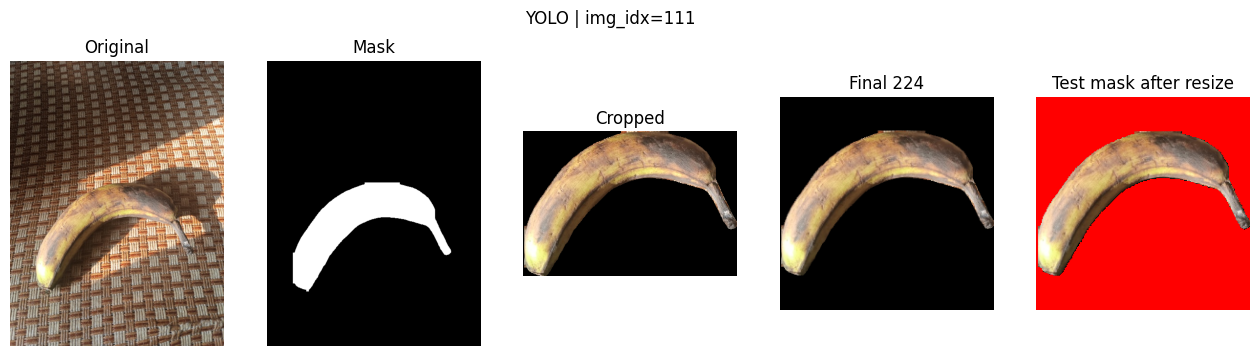

final image size: (224, 224, 3)


In [ ]:
visual_2 = process_banana_224(
    train_images[111],
    img_idx=111,
    manual_mode=False,
    debug=True
)

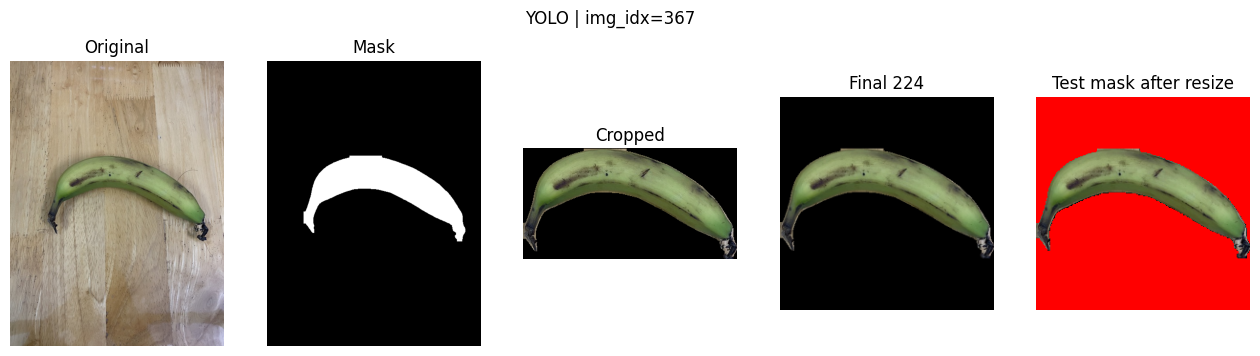

final image size: (224, 224, 3)


In [ ]:
visual_3 = process_banana_224(
    train_images[367],
    img_idx=367,
    manual_mode=False,
    debug=True
)

In [ ]:
def rotate_image_and_mask(image, mask, angle):
    """
    Xoay cả ảnh và mask theo một góc bất kỳ mà không làm thay đổi kích thước 224x224.
    """
    (h, w) = image.shape[:2]
    center = (w // 2, h // 2)

    # Tạo ma trận xoay
    M = cv2.getRotationMatrix2D(center, angle, 1.0)

    # Thực hiện xoay ảnh (dùng INTER_LINEAR cho ảnh)
    rotated_img = cv2.warpAffine(image, M, (w, h), flags=cv2.INTER_LINEAR)

    # Thực hiện xoay mask (dùng INTER_NEAREST để giữ nguyên giá trị 0 và 255)
    rotated_mask = cv2.warpAffine(mask, M, (w, h), flags=cv2.INTER_NEAREST)

    return rotated_img, rotated_mask

In [ ]:
def add_gaussian_noise(image, sigma=15):
    """
    Thêm nhiễu Gaussian vào ảnh.
    - sigma: Độ lệch chuẩn của phân phối Gaussian
    """
    row, col, ch = image.shape
    mean = 0
    # Tạo nhiễu ngẫu nhiên
    gauss = np.random.normal(mean, sigma, (row, col, ch))
    # Cộng nhiễu vào ảnh và ép kiểu về uint8
    noisy = np.clip(image.astype(np.float32) + gauss, 0, 255).astype(np.uint8)
    return noisy

In [ ]:
# Hàm TĂNG CƯỜNG ẢNH BẰNG OPENCV (DATA AUGMENTATION)
def augment_image(img, mask):
    """
    Tạo ra các phiên bản biến đổi của ảnh gốc để tăng cường dữ liệu.
    """
    augmented_pairs = []
    # Ảnh gốc
    augmented_pairs.append((img, mask))

    # Thêm nhiễu
    img_noise = add_gaussian_noise(img)
    augmented_pairs.append((img_noise, mask))

    # Lật ngang (Horizontal Flip)
    img_flip_h = cv2.flip(img, 1)
    mask_flip_h = cv2.flip(mask, 1)
    augmented_pairs.append((img_flip_h, mask_flip_h))

    # Tăng độ sáng (Giả lập chụp dưới đèn mạnh)
    # Tăng thêm 30 đơn vị vào kênh V trong HSV
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    h, s, v = cv2.split(hsv)
    v = cv2.add(v, 30)
    img_bright = cv2.cvtColor(cv2.merge([h, s, v]), cv2.COLOR_HSV2BGR)
    augmented_pairs.append((img_bright, mask))

    # Giảm độ sáng (Giả lập chụp thiếu sáng)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    h, s, v = cv2.split(hsv)
    v = cv2.subtract(v, 30)
    img_dark = cv2.cvtColor(cv2.merge([h, s, v]), cv2.COLOR_HSV2BGR)
    augmented_pairs.append((img_dark, mask))

    return augmented_pairs

#Với bài toán phân loại màu sắc, chúng ta nên ưu tiên tăng cường những thứ làm
#thay đổi giá trị Vector đặc trưng thay vì chỉ thay đổi vị trí điểm ảnh.
#Đề xuất 3 hướng chính:
#Thay đổi độ sáng (Brightness/Value): Rất quan trọng vì chuối chụp ở điều kiện thiếu sáng sẽ khác chuối chụp dưới đèn led.
#Lật ngang (Horizontal Flip): Để bù đắp sự bất đối xứng của camera, 1 lần là đủ.
#Nhiễu nhẹ (Gaussian Noise): Để mô hình không bị "sốc" khi ảnh bị nhiễu hạt.

In [ ]:
def show_augmentations(augmented_pairs, title="Data Augmentation Results"):
    """
    Hiển thị danh sách các cặp ảnh và mask đã được tăng cường.
    """
    n = len(augmented_pairs)
    fig, axes = plt.subplots(2, n, figsize=(n * 3, 6))

    for i in range(n):
        img, mask = augmented_pairs[i]

        # Hiển thị ảnh (Chuyển BGR sang RGB để matplotlib hiển thị đúng màu)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[0, i].imshow(img_rgb)
        if i == 0:
          axes[0, i].set_title(f"Original")
        elif i == 2:
          axes[0, i].set_title(f"Flip Horizontal")
        elif i == 1:
          axes[0, i].set_title(f"Noise")
        elif i == 3:
          axes[0, i].set_title(f"Brighten")
        elif i == 4:
          axes[0, i].set_title(f"Darken")

        axes[0, i].axis('off')

        # Hiển thị mask
        axes[1, i].imshow(mask, cmap='gray')
        axes[1, i].axis('off')

    plt.tight_layout()
    plt.suptitle(title, fontsize=16, y=1.05)
    plt.show()

# --- VÍ DỤ SỬ DỤNG ---
# Giả sử bạn đã có final_img và final_mask từ hàm process_banana_224
# result_pairs = augment_image(final_img, final_mask)
# show_augmentations(result_pairs)

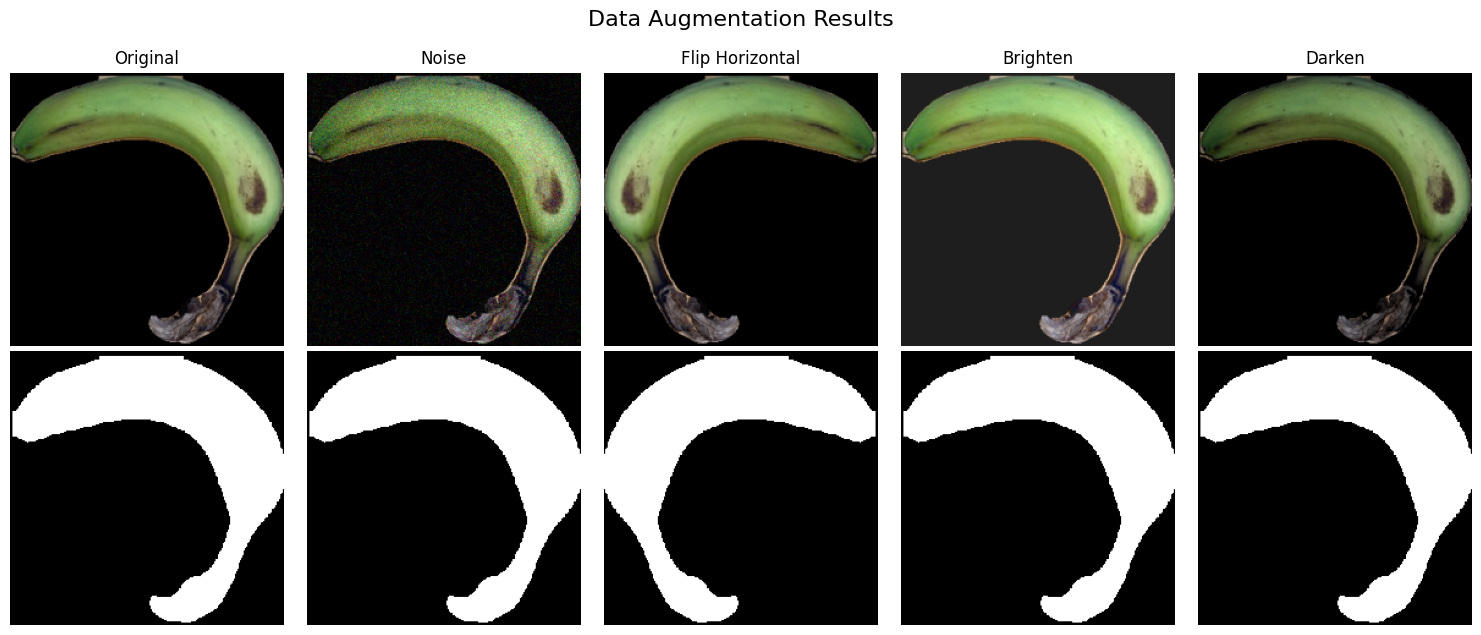

In [ ]:
final_img, final_mask = process_banana_224(train_images[362])
result_pairs = augment_image(final_img, final_mask)
show_augmentations(result_pairs)

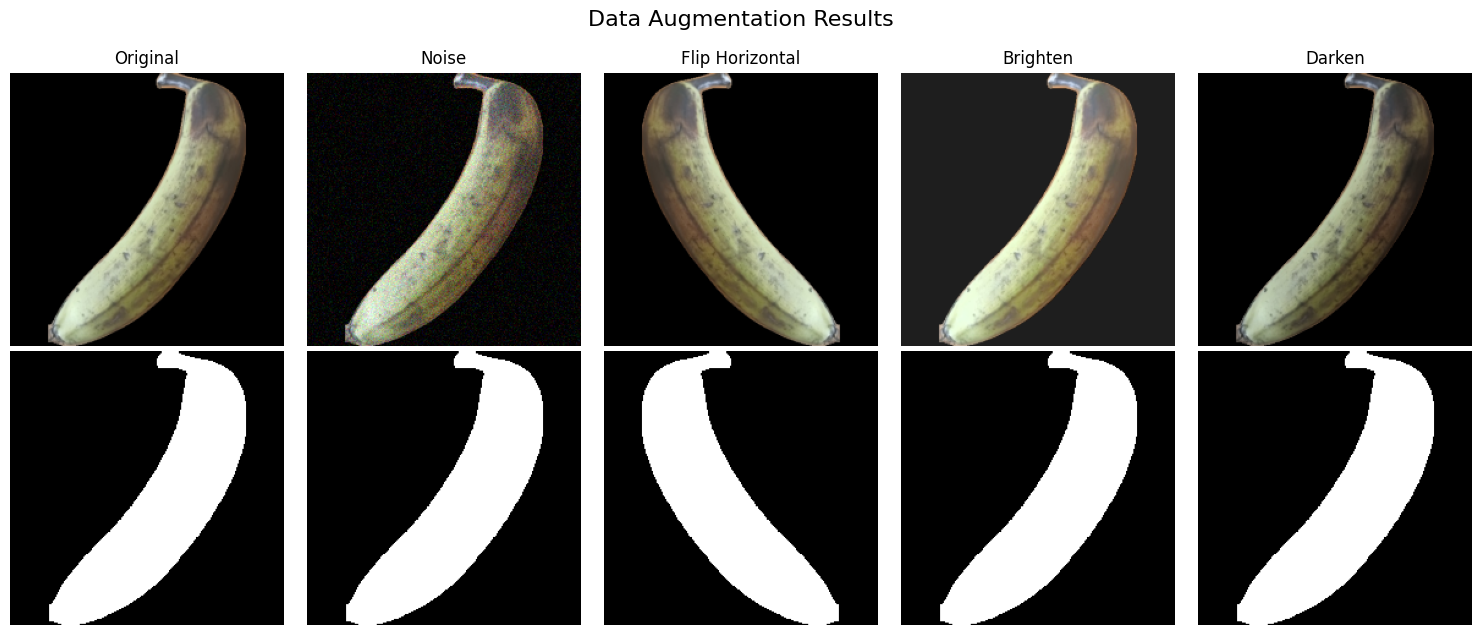

In [ ]:
final_img, final_mask = process_banana_224(train_images[156])
result_pairs = augment_image(final_img, final_mask)
show_augmentations(result_pairs)

# **Trích xuất đặc trưng**

In [ ]:
def preprocess_image(img, mask, filter_type='median'):
    """
    Nhận trực tiếp final_img và final_mask từ YOLO để tối ưu hiệu suất.
    """
    if filter_type == 'gaussian':
        img_filtered = cv2.GaussianBlur(img, (5, 5), 0)
    else:
        img_filtered = cv2.medianBlur(img, 5)

    img_hsv = cv2.cvtColor(img_filtered, cv2.COLOR_BGR2HSV)
    h, s, v = cv2.split(img_hsv)

    # Dùng mask để chỉ tính Histogram (CLAHE) trên phần quả chuối, tránh nhiễu nền đen
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    v_eq = clahe.apply(v)

    img_hsv_eq = cv2.merge((h, s, v_eq))

    # Output ảnh HSV và mask
    return img_hsv_eq, mask

In [ ]:
def extract_color_features(img_hsv, mask, k_clusters=3, w1=0.3, w2=0.4, w3=0.3):
    """
    Sử dụng K-means để tìm cụm màu và tính toán các đặc trưng Ck, Ak, Sk, pk.
    """
    banana_pixels = img_hsv[mask == 255]
    if len(banana_pixels) == 0:
        return None # Tránh lỗi nếu mask trống

    pixel_data = np.float32(banana_pixels)

    # K-Means phân cụm màu
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    labels = kmeans.fit_predict(pixel_data)
    centers = kmeans.cluster_centers_

    v_channel = img_hsv[:, :, 2]
    sobelx = cv2.Sobel(v_channel, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(v_channel, cv2.CV_64F, 0, 1, ksize=3)
    gradient_magnitude = np.sqrt(sobelx**2 + sobely**2)
    gradient_pixels = gradient_magnitude[mask == 255]

    _, counts = np.unique(labels, return_counts=True)
    max_area = np.max(counts)

    green_ratio, yellow_ratio, brown_ratio = 0.0, 0.0, 0.0
    pk_list = []

    for i in range(k_clusters):
        cluster_mask = (labels == i)
        Ak = counts[i] / max_area
        Sk = centers[i][1] / 255.0
        Ck = np.mean(gradient_pixels[cluster_mask])
        Ck_normalized = min(Ck / 255.0, 1.0)

        pk = w1 * Ck_normalized + w2 * Ak + w3 * Sk
        pk_list.append(pk)

        hue = centers[i][0]
        area_ratio = counts[i] / len(banana_pixels)
        if 35 <= hue <= 85: green_ratio += area_ratio
        elif 20 < hue < 35: yellow_ratio += area_ratio
        else: brown_ratio += area_ratio

    mean_pk = np.mean(pk_list)

    moments = []
    for i in range(3):
        channel_pixels = banana_pixels[:, i]
        mean_val = np.mean(channel_pixels) / 255.0
        std_val = np.std(channel_pixels) / 255.0
        skew_val = skew(channel_pixels)
        moments.extend([mean_val, std_val, skew_val])

    feature_vector = [yellow_ratio, green_ratio, brown_ratio, mean_pk] + moments
    return feature_vector

In [ ]:
# Hàm trích xuất đặc trưng
def compute_feature(img, mask):
    """
    Hàm trích xuất đặc trưng màu sắc.
    """
    # Tiền xử lý để lấy ảnh HSV đã được cân bằng sáng
    img_hsv, processed_mask = preprocess_image(img, mask)

    features = extract_color_features(img_hsv, processed_mask)

    return features

# **Toàn bộ code dưới đây dùng chung**

In [ ]:
# --- TẬP TRAIN: AUGMENT -> TRÍCH XUẤT ---
X_train = []
y_train = []

print("Đang thực hiện Augment và Trích xuất đặc trưng tập TRAIN...")

for idx, img in enumerate(tqdm(train_images)):
    # 1. Phân đoạn ảnh gốc để lấy mask chuẩn
    final_img, final_mask = process_banana_224(img)

    # Kiểm tra nếu phân đoạn thất bại
    if final_img is None or final_mask is None:
        print("Phân đoạn quả chuối thất bại")
        # Sử dụng ảnh đen và mask đen thay thế để các hàm sau không bị lỗi logic
        final_img = np.zeros((224, 224, 3), dtype=np.uint8)
        final_mask = np.zeros((224, 224), dtype=np.uint8)

    # Tạo danh sách ảnh tăng cường từ ảnh đã phân đoạn
    # Hàm augment_image trả về list các cặp [(img1, m1), (img2, m2),...]
    pairs = augment_image(final_img, final_mask)

    for aug_img, aug_mask in pairs:
        # Trích xuất đặc trưng cho từng bản augment
        feature = compute_feature(aug_img, aug_mask)

        if feature is not None:
            X_train.append(feature)
            # Mỗi bản augment đều mang nhãn của ảnh gốc
            y_train.append(train_labels[idx])


# --- TẬP TEST: TRÍCH XUẤT (KHÔNG AUGMENT) ---
X_test = []
y_test = []

print("\nĐang trích xuất đặc trưng tập TEST...")
for idx, img in enumerate(tqdm(test_images)):
    # 1. Phân đoạn ảnh gốc để lấy mask chuẩn
    final_img, final_mask = process_banana_224(img)

    # Kiểm tra nếu phân đoạn thất bại
    if final_img is None or final_mask is None:
        print("Phân đoạn quả chuối thất bại")
        # Sử dụng ảnh đen và mask đen thay thế để các hàm sau không bị lỗi logic
        final_img = np.zeros((224, 224, 3), dtype=np.uint8)
        final_mask = np.zeros((224, 224), dtype=np.uint8)

    # Trích xuất đặc trưng
    feature = compute_feature(final_img, final_mask)

    if feature is not None:
        X_test.append(feature)
        y_test.append(test_labels[idx])

# Chuyển sang numpy array
X_train = np.array(X_train)
y_train = np.array(y_train)
X_test = np.array(X_test)
y_test = np.array(y_test)

print(f"\n✅ HOÀN TẤT TRÍCH XUẤT")
print(f"Kích thước tập Train: {X_train.shape}, {y_train.shape}")
print(f"Kích thước tập Test:  {X_test.shape}, {y_test.shape}")

Đang thực hiện Augment và Trích xuất đặc trưng tập TRAIN...


100%|██████████| 480/480 [47:48<00:00,  5.98s/it]



Đang trích xuất đặc trưng tập TEST...


100%|██████████| 120/120 [10:43<00:00,  5.36s/it]


✅ HOÀN TẤT TRÍCH XUẤT
Kích thước tập Train: (2400, 13), (2400,)
Kích thước tập Test:  (120, 13), (120,)


# Train

In [ ]:
def evaluate(name, y_true, y_pred):
    print(f"===== {name} =====")
    print(f"F1 Macro: {f1_score(y_true, y_pred, average='macro'):.4f}")
    print(classification_report(y_true, y_pred))

    cm = confusion_matrix(y_true, y_pred)
    print("Confusion Matrix:")
    print(cm)

    plt.figure()
    plt.imshow(cm)
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha='center', va='center')

    plt.colorbar()
    plt.show()



📊 BÁO CÁO CHI TIẾT TRÊN TẬP KIỂM TRA (TEST SET):
===== Test =====
F1 Macro: 0.8987
              precision    recall  f1-score   support

           0       0.94      0.80      0.86        40
           1       0.84      0.90      0.87        40
           2       0.93      1.00      0.96        40

    accuracy                           0.90       120
   macro avg       0.90      0.90      0.90       120
weighted avg       0.90      0.90      0.90       120

Confusion Matrix:
[[32  7  1]
 [ 2 36  2]
 [ 0  0 40]]


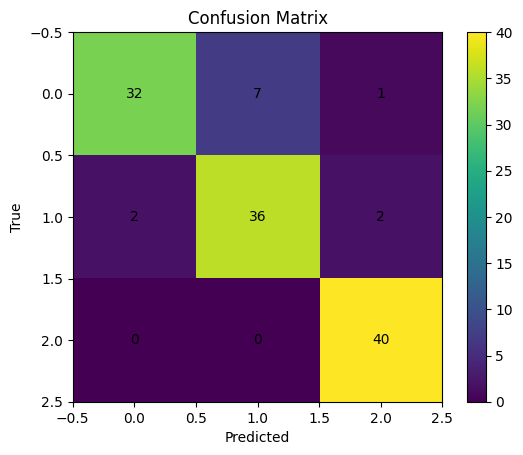

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model_knn = KNeighborsClassifier(n_neighbors=5, metric='manhattan', weights='distance')
model_knn.fit(X_train_scaled, y_train)
y_test_pred = model_knn.predict(X_test_scaled)

print("\n📊 BÁO CÁO CHI TIẾT TRÊN TẬP KIỂM TRA (TEST SET):")
evaluate("Test", y_test, y_test_pred)

In [ ]:
def save_model(model, scaler, model_path='knn_banana_model.pkl', scaler_path='scaler.pkl'):
    """
    Lưu mô hình KNN và bộ chuẩn hóa Scaler vào file.
    """
    try:
        joblib.dump(model, model_path)
        joblib.dump(scaler, scaler_path)
        print(f"✅ Đã lưu mô hình thành công tại: {model_path}")
        print(f"✅ Đã lưu bộ chuẩn hóa thành công tại: {scaler_path}")
    except Exception as e:
        print(f"❌ Lỗi khi lưu mô hình: {e}")

# Gọi hàm để lưu sau khi đã train xong knn_model và scaler
save_model(model_knn, scaler)

✅ Đã lưu mô hình thành công tại: knn_banana_model.pkl
✅ Đã lưu bộ chuẩn hóa thành công tại: scaler.pkl


In [ ]:
def predict_new_image(image_path, model, scaler, class_names):
    # 1. Đọc ảnh mới
    raw_img = cv2.imread(image_path)
    if raw_img is None:
        print("Không đọc được ảnh!")
        return

    # 2. Phân đoạn để lấy vùng chứa quả chuối (tránh dùng biến global)
    # manual_mode=False để YOLO tự chạy
    final_img, final_mask = process_banana_224(raw_img)

    # Hiển thị ảnh final_img và final_mask
    show_image(final_img)
    show_image(final_mask)

    # Kiểm tra nếu phân đoạn thất bại
    if final_img is None or final_mask is None:
        print("Phân đoạn quả chuối thất bại")
        # Sử dụng ảnh đen và mask đen thay thế để các hàm sau không bị lỗi logic
        final_img = np.zeros((224, 224, 3), dtype=np.uint8)
        final_mask = np.zeros((224, 224), dtype=np.uint8)

    # Trích xuất đặc trưng
    feature = compute_feature(final_img, final_mask)

    if not feature:
        print("Lỗi trích xuất đặc trưng!")
        return

    # 4. Lấy vector duy nhất đó và chuẩn hóa
    current_feat = np.array(feature).reshape(1, -1)
    feat_scaled = scaler.transform(current_feat)

    # 5. Dự đoán
    pred_idx = model.predict(feat_scaled)[0]
    prob = model.predict_proba(feat_scaled)[0]

    label = class_names[pred_idx]
    confidence = prob[pred_idx] * 100

    # 6. Hiển thị (Dùng trực tiếp p_img vừa xử lý)
    plt.figure(figsize=(8, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB))
    plt.title("Ảnh gốc")

    plt.subplot(1, 2, 2)
    plt.imshow(cv2.cvtColor(final_img, cv2.COLOR_BGR2RGB))
    plt.title(f"Dự đoán: {label} ({confidence:.2f}%)")
    plt.show()

    print(f"--- KẾT QUẢ CUỐI CÙNG: {label} ---")

In [ ]:
def load_trained_model(model_path='knn_banana_model.pkl', scaler_path='scaler.pkl'):
    """
    Tải mô hình và scaler đã lưu để sẵn sàng dự đoán.
    """
    model = joblib.load(model_path)
    scaler = joblib.load(scaler_path)
    print("🚀 Mô hình và Scaler đã sẵn sàng!")
    return model, scaler

In [ ]:
# Sử dụng trong demo:
my_model, my_scaler = load_trained_model()

🚀 Mô hình và Scaler đã sẵn sàng!


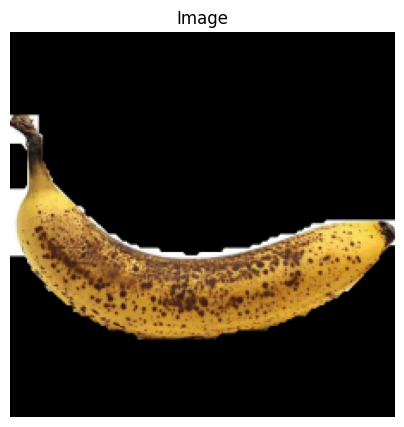

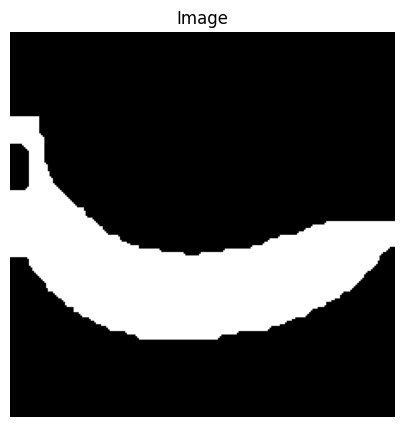

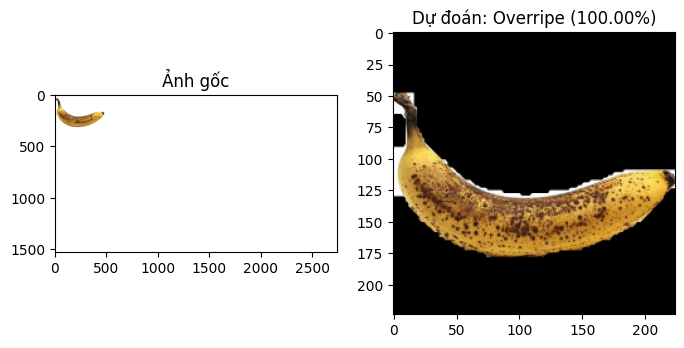

--- KẾT QUẢ CUỐI CÙNG: Overripe ---


In [ ]:
predict_new_image("/content/dd.png", my_model, my_scaler, class_names)